# 0. 导入必要的库

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import ToPILImage
show = ToPILImage()

# 1. 准备训练数据与测试数据
首先我们介绍数据部分。`torchvision`库已经为我们直接提供了CIFAR-10数据集的下载，我们就不需要手动地去网上下载了。代码中的`transform`将原始的图像转换为模型易于处理的形式。`trainloader`和`testloader`分别用于加载训练集和测试集。

In [ ]:
# 设定对图片的归一化处理方式，并且下载数据集
import os
os.makedirs('./dataset', exist_ok=True)

# 数据增强策略：训练时使用增强，测试时只使用基本归一化
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 64  # 根据RTX 4090调整，从4增加到64

# 加载完整训练集
full_trainset = torchvision.datasets.CIFAR10(root='./dataset', train=True,
                                        download=True, transform=transform_train)

# 分割训练集和验证集（90%训练，10%验证）
train_size = int(0.9 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = torch.utils.data.random_split(full_trainset, [train_size, val_size])

# 创建数据加载器
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                        shuffle=False, num_workers=2)

# 测试集
testset = torchvision.datasets.CIFAR10(root='./dataset', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

print(f"训练集大小: {len(trainset)}")
print(f"验证集大小: {len(valset)}")
print(f"测试集大小: {len(testset)}")

通过运行下面的代码，可得知CIFAR-10数据集的训练集包含50000张图像，每张图像的大小为32*32；数据集中的每个元素是由数据和对应的标签组成的。

In [5]:
# 观察一下数据集的内容
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck') # 类别名称
print(len(trainset)) # 训练集大小
print(trainset[0][0].size()) # 第 1 条数据的图像大小
print(trainset[0][1]) # 第 1 条数据的标签
print(classes[trainset[0][1]]) # 第 1 条数据的文本标签

50000
torch.Size([3, 32, 32])
6
frog


下面这段代码在训练集中随意抽出一张进行可视化，注意在展示之前我们需要将其做上述`transform`的逆变换：

torch.Size([3, 32, 32])
7
horse


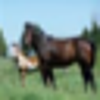

In [6]:
# 1 - 4行与上一块代码意义类似
(data, label) = trainset[12] # 选群训练集的一个样本展示内容，也可以改成其他数字看看
print(data.size()) 
print(label) # label是整数
print(classes[label])
show((data + 1) / 2).resize((100, 100)) # 还原被归一化的图片

# 2. 定义用于分类的网络结构

这一部分我们定义用于图像分类的网络结构，实现一个早期的卷积神经网络LeNet。它由两个卷积层和三个全连接层组成。pytorch为我们提供了方便的接口定义神经网络，但我们这里不着重介绍具体的语法，只观察数据是怎样在模型中“流动”的：
- 在`__init__`方法中，我们将上述的卷积层和全连接层初始化为`conv1、conv2`和`fc1、fc2、fc3`；
- 卷积层以`conv1`为例，它的初始化为`Conv2d(3, 6, 5)`，即：3输入通道（RGB图像的三个通道）、6输出通道、5*5大小的卷积核的卷积层。
- 全连接层以`fc1`为例，它的初始化为`Linear(16 * 5 * 5, 120)`，即：从400维映射到120维。
- `forward`方法用于规定数据在模型中的计算过程。输入的形状在传播过程中的变化参见`forward`中的注释。最终，我们得到了一个大小为`[batch size, 10]`的张量（矩阵）。

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        # nn.Module子类的函数必须在构造函数中执行父类的构造函数
        super(Net, self).__init__()

        # 卷积层 '3'表示输入图片为单通道, '6'表示输出通道数，'5'表示卷积核为5*5
        self.conv1 = nn.Conv2d(3, 6, 5) 
        # 卷积层
        self.conv2 = nn.Conv2d(6, 16, 5) 
        # 仿射层/全连接层，y = Wx + b
        self.fc1   = nn.Linear(16*5*5, 120) 
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x): 
        # 卷积 -> 激活 -> 池化 (relu激活函数不改变输入的形状)
        # [batch size, 3, 32, 32] -- conv1 --> [batch size, 6, 28, 28] -- maxpool --> [batch size, 6, 14, 14]
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # [batch size, 6, 14, 14] -- conv2 --> [batch size, 16, 10, 10] --> maxpool --> [batch size, 16, 5, 5]
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        # 把 16 * 5 * 5 的特征图展平，变为 [batch size, 16 * 5 * 5]，以送入全连接层
        x = x.view(x.size()[0], -1) 
        # [batch size, 16 * 5 * 5] -- fc1 --> [batch size, 120]
        x = F.relu(self.fc1(x))
        # [batch size, 120] -- fc2 --> [batch size, 84]
        x = F.relu(self.fc2(x))
        # [batch size, 84] -- fc3 --> [batch size, 10]
        x = self.fc3(x)        
        return x

net = Net()
print(net)

Net1(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


# 3. 模型训练与测试过程
准备好数据、定义好模型后，我们开始训练过程。为了把一个随机初始化的模型优化成一个“好”的模型，我们还需要定义：
- 损失函数$\mathcal{L}$：损失函数以一般同时以模型的预测$\hat{y}$和真实的标签$y$为输入，输出一个标量。这个标量越小，说明模型在数据上拟合得越好。我们的目的就是要最小化这个损失函数$\mathcal{L}(\hat{y},y).$分类问题常使用交叉熵函数作为损失函数。
- 优化方法：为了最小化损失函数，我们就要使用数学的优化方法找到一组最优的参数（这里的参数即神经网络中卷积层、全连接层等的参数，而非batch size等超参数）。深度学习中一般使用迭代的方式求解，常用的方法有SGD（随机梯度下降）、Adam等。
pytorch库内置了各种优化器，我们无需手动实现梯度下降过程。

In [8]:
from torch import optim
criterion = nn.CrossEntropyLoss() # 交叉熵损失函数
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # 使用SGD（随机梯度下降）优化
num_epochs = 5 # 训练 5 个 epoch

下面我们定义用于训练过程的代码。最外层循环控制在整个数据集上训练的次数（即epoch）；内层循环按照以下流程进行：
1. 取出数据（一次取出一个batch）；
2. 将数据送入网络，计算损失函数；
3. 使用损失函数计算梯度，进行反向传播更新参数。

In [ ]:
def train(trainloader, net, num_epochs, criterion, optimizer, save_path, valloader=None, early_stopping_patience=None):
    """
    训练神经网络模型
    
    Args:
        trainloader: 训练数据加载器
        net: 神经网络模型
        num_epochs: 训练轮数
        criterion: 损失函数
        optimizer: 优化器
        save_path: 模型保存路径
        valloader: 验证数据加载器（可选）
        early_stopping_patience: 早停耐心值（可选）
    
    Returns:
        train_losses: 每个epoch的平均训练损失列表
        val_accuracies: 每个epoch的验证准确率列表（如果有验证集）
    """
    import os
    os.makedirs(save_path, exist_ok=True)
    
    train_losses = []  # 记录每个epoch的平均训练损失
    val_accuracies = []  # 记录每个epoch的验证准确率
    
    best_val_accuracy = 0.0
    patience_counter = 0
    patience = early_stopping_patience if early_stopping_patience is not None else float('inf')
    
    device = next(net.parameters()).device
    print(f"Training on device: {device}")
    
    for epoch in range(num_epochs):     
        running_loss = 0.0
        total_batches = 0
        
        # 训练阶段
        net.train()
        for i, data in enumerate(trainloader, 0):
            # 1. 取出数据
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
    
            # 梯度清零
            optimizer.zero_grad()
    
            # 2. 前向计算和反向传播
            outputs = net(inputs) # 送入网络（正向传播）
            loss = criterion(outputs, labels) # 计算损失函数
            
            # 3. 反向传播，更新参数
            loss.backward() # 反向传播
            
            # 梯度裁剪（防止梯度爆炸）
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
            
            optimizer.step()

            # 记录损失
            running_loss += loss.item()
            total_batches += 1
            
            # 每1000个batch打印一下训练状态
            if i % 1000 == 999:
                avg_loss = running_loss / total_batches
                print(f'epoch {epoch+1}: batch {i+1:5d} loss: {avg_loss:.3f}')
        
        # 计算该epoch的平均训练损失
        epoch_avg_loss = running_loss / total_batches if total_batches > 0 else 0
        train_losses.append(epoch_avg_loss)
        
        # 验证阶段（如果有验证集）
        if valloader is not None:
            net.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for data in valloader:
                    images, labels = data
                    images, labels = images.to(device), labels.to(device)
                    outputs = net(images)
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
            
            val_accuracy = 100 * correct / total
            val_accuracies.append(val_accuracy)
            
            print(f'Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_avg_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')
            
            # 早停逻辑
            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                patience_counter = 0
                # 保存最佳模型
                torch.save(net.state_dict(), f"{save_path}/best_model.pth")
                print(f'  -> New best model saved with accuracy: {val_accuracy:.2f}%')
            else:
                patience_counter += 1
                print(f'  -> No improvement for {patience_counter} epoch(s)')
                
            if patience_counter >= patience:
                print(f'Early stopping triggered at epoch {epoch+1}')
                break
        else:
            print(f'Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_avg_loss:.4f}')
        
        # 保存每个epoch的检查点
        torch.save(net.state_dict(), f"{save_path}/epoch_{epoch + 1}_model.pth")
        
    print('Finished Training')
    
    if valloader is not None:
        return train_losses, val_accuracies
    else:
        return train_losses

In [ ]:
# 设置设备（GPU如果可用）
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 将模型移动到设备
net = Net()
net = net.to(device)

# 使用定义的网络进行训练
save_path = 'checkpoints/lenet_baseline'
train_losses, val_accuracies = train(trainloader, net, num_epochs, criterion, optimizer, save_path, valloader=valloader, early_stopping_patience=10)

# 绘制损失曲线
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Final validation accuracy: {val_accuracies[-1]:.2f}%")

训练过程结束后，我们得到了一个在训练集上拟合较好的模型。下面我们要测试它在测试集上表现如何。预测的代码与训练中的正向传播类似，但是不需要计算损失函数（损失函数在实验中仅用于更新参数，预测时参数固定，也就不需要它了）。

预测的流程如下：
1. 取出数据；
2. 正向传播，得到模型的输出结果；
3. 从输出结果中得到模型预测；
4. 和真实标签进行比对，计算性能指标。

注意：模型的输出结果在第2部分中已经说明，为一个`[batch size, 10]`大小的张量（矩阵），每一行是一条数据属于10个类别的概率的相对大小（这一输出也被称为`logits`）。为了得到模型的预测，我们需要对这一输出在每行上取最大值，取得最大值的**位置**就是模型的预测。

In [ ]:
def predict(testloader, net):
    correct = 0 # 预测正确的图片数
    total = 0 # 总共的图片数
    
    device = next(net.parameters()).device
    net.eval()
    
    with torch.no_grad(): # 正向传播时不计算梯度
        for data in testloader:
            # 1. 取出数据
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            # 2. 正向传播，得到输出结果
            outputs = net(images)
            # 3. 从输出中得到模型预测
            _, predicted = torch.max(outputs, 1)
            # 4. 计算性能指标
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f'测试集中的准确率为: {accuracy:.2f} %')
    return accuracy

In [20]:
predict(testloader, net)

测试集中的准确率为: 59 %



# Task1：绘制损失函数曲线
损失函数能够量化模型在数据集上的拟合程度，帮助我们了解模型训练的进程。请在`3.模型训练与测试过程`中补充代码，记录训练过程中损失`loss`的变化，使用合适的Python数据类型将其保存，并使用`matplotlib`库将其可视化。可参照以下的代码进行绘图。你可以直接用损失函数可视化的代码覆盖下面的代码块。

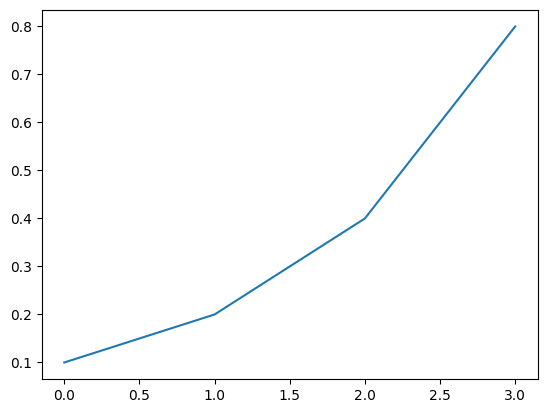

In [9]:
import matplotlib.pyplot as plt

def draw(values):
    plt.plot(values)
    plt.show()

draw([0.1, 0.2, 0.4, 0.8])

请在报告中附上训练过程中损失函数的变化。训练集上的损失越小，说明模型的效果就越好吗？

# Task2: 加入正则化

- $L_2$正则化：请查阅Pytorch[有关SGD优化器的文档](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#sgd)或其它网络资料，修改`3. 模型训练与测试过程`中的代码，尝试为模型的损失函数加入一项$L_2$损失，并在报告中说明你所做的修改。
- Dropout正则化：请查阅Pytorch[有关Dropout层的文档](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#dropout)或其它网络资料，修改`2. 定义用于分类的网络结构`中的代码，在**第一个线性层和第二个线性层之间**加入一个Dropout层，并在报告中说明你所做的修改。
- 在报告中简述两种正则化方法的基本原理。

In [ ]:
# TODO: 在Dropout_Net中加入dropout层
class Dropout_Net(nn.Module):
    def __init__(self):
        # nn.Module子类的函数必须在构造函数中执行父类的构造函数
        super(Dropout_Net, self).__init__()

        # 卷积层 '1'表示输入图片为单通道, '6'表示输出通道数，'5'表示卷积核为5*5
        self.conv1 = nn.Conv2d(3, 6, 5) 
        # 卷积层
        self.conv2 = nn.Conv2d(6, 16, 5) 
        # 仿射层/全连接层，y = Wx + b
        self.fc1   = nn.Linear(16*5*5, 120) 
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x): 
        # 卷积 -> 激活 -> 池化 
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2) 
        # reshape，‘-1’表示自适应
        x = x.view(x.size()[0], -1) 
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)        
        return x
    
dropout_net = Dropout_Net()

In [ ]:
# TODO: 在这里重新定义optimizer，加入L2正则化项

# 使用新定义的网络和优化器进行训练与测试
train(trainloader, dropout_net, num_epochs, criterion, optimizer)
predict(testloader, dropout_net)

# Task3: 调整参数
在`3. 模型训练与测试过程`部分中，我们定义了一些超参数（如`num_epoch`、优化器的`lr`）。调节这些参数，观察损失函数以及模型在测试集上的性能变化，在报告中简要说明这些指标的变化，尝试分析这些超参数对整个模型的影响。

In [ ]:
# TODO: 在这里修改参数，重新进行训练和测试，并记录数据

# Task4: 实现自己的网络
查阅资料（参考：[动手学深度学习](https://zh.d2l.ai/chapter_convolutional-modern/index.html)以及[`torchvision`的模型源码](https://github.com/pytorch/vision/tree/main/torchvision/models)），修改`2. 定义用于分类的网络结构`中的代码，实现一种现代卷积神经网络。与最基础的LeNet相比，你实现的神经网络在性能、训练时间上有何差异？

In [ ]:
# TODO: 参考2.中Net的实现，设计自己的网络，进行训练和测试，并记录数据